In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'

os.chdir('/content/drive/MyDrive/resnet-transfer-learning')
print(os.getcwd())
print(os.listdir())

/content/drive/MyDrive/resnet-transfer-learning
['metadata.csv', 'dataset_raw']


In [ ]:
import tensorflow as tf
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import json
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
df = pd.read_csv('metadata.csv')
print("Total data:", len(df))
print("Distribusi kelas:\n", df['label'].value_counts())

class_names = sorted(df['label'].unique())
label_to_idx = {name: idx for idx, name in enumerate(class_names)}
df['label_idx'] = df['label'].map(label_to_idx)
num_classes = len(class_names)

print("\nKelas:", class_names)
print("Jumlah kelas:", num_classes)

total = len(df)
if total < 100:
    print(f"⚠️  PERINGATAN: Dataset hanya {total} gambar. Test set akan sangat kecil.")
if df['label'].value_counts().min() < 50:
    print(f"⚠️  PERINGATAN: Ada kelas dengan < 50 gambar. Tidak memenuhi syarat tugas.")

Total data: 100
Distribusi kelas:
 label
landing_pad        50
not_landing_pad    50
Name: count, dtype: int64

Kelas: ['landing_pad', 'not_landing_pad']
Jumlah kelas: 2


In [ ]:
train_df, temp_df = train_test_split(
    df, test_size=0.30, stratify=df['label_idx'], random_state=SEED
)
val_df, test_df = train_test_split(
    temp_df, test_size=1/3, stratify=temp_df['label_idx'], random_state=SEED
)

print("Split data:")
print(f"  Train : {len(train_df):>4} ({len(train_df)/total*100:.1f}%)")
print(f"  Val   : {len(val_df):>4} ({len(val_df)/total*100:.1f}%)")
print(f"  Test  : {len(test_df):>4} ({len(test_df)/total*100:.1f}%)")

print("\nCek distribusi kelas per split:")
for name, split_df in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    counts = split_df['label'].value_counts().to_dict()
    print(f"  {name}: {counts}")

train_df[['filename', 'label']].to_csv('split_train.csv', index=False)
val_df[['filename', 'label']].to_csv('split_val.csv', index=False)
test_df[['filename', 'label']].to_csv('split_test.csv', index=False)
print("\nDaftar split disimpan: split_train.csv, split_val.csv, split_test.csv")

Split data:
  Train :   70 (70.0%)
  Val   :   20 (20.0%)
  Test  :   10 (10.0%)

Cek distribusi kelas per split:
  Train: {'not_landing_pad': 35, 'landing_pad': 35}
  Val: {'not_landing_pad': 10, 'landing_pad': 10}
  Test: {'landing_pad': 5, 'not_landing_pad': 5}

Daftar split disimpan: split_train.csv, split_val.csv, split_test.csv


In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

def load_and_preprocess_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image = tf.image.resize(image, IMG_SIZE)

    image = tf.cast(image, tf.float32)
    image = image / 255.0  # Skala ke [0, 1]

    mean = tf.constant([0.485, 0.456, 0.406])
    std  = tf.constant([0.229, 0.224, 0.225])

    image = (image - mean) / std

    return image, label

def create_dataset(dataframe, shuffle=False):
    paths = dataframe['path'].values
    labels = dataframe['label_idx'].values
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(dataframe), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(load_and_preprocess_image, num_parallel_calls=1)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

train_ds = create_dataset(train_df, shuffle=True)
val_ds   = create_dataset(val_df,   shuffle=False)
test_ds  = create_dataset(test_df,  shuffle=False)

# Cek satu batch
for images, labels in train_ds.take(1):
    print("Shape batch:", images.shape, "| Labels shape:", labels.shape)

Shape batch: (32, 224, 224, 3) | Labels shape: (32,)


In [ ]:
def build_model(mode='feature_extraction', num_classes=2, use_augmentation=False):
    # --- Validasi mode ---
    valid_modes = ['feature_extraction', 'fine_tuning_partial', 'fine_tuning_full']
    if mode not in valid_modes:
        raise ValueError(f"Mode tidak dikenal: {mode}. Pilih dari {valid_modes}")

    # --- Base model ResNet-50 ---
    base_model = tf.keras.applications.ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=(224, 224, 3)
    )

    # --- Konfigurasi trainable layer ---
    if mode == 'feature_extraction':
        base_model.trainable = False

    elif mode == 'fine_tuning_partial':
        base_model.trainable = True
        UNFREEZE_LAST_N = 30
        for layer in base_model.layers[:-UNFREEZE_LAST_N]:
            layer.trainable = False
        for layer in base_model.layers[-UNFREEZE_LAST_N:]:
            layer.trainable = True

    elif mode == 'fine_tuning_full':
        base_model.trainable = True

    # --- Head classifier ---
    layers_list = []

    # Augmentasi
    if use_augmentation:
        layers_list.extend([
            tf.keras.layers.RandomFlip('horizontal'),
            tf.keras.layers.RandomRotation(0.1, fill_mode='reflect'),
            tf.keras.layers.RandomZoom(0.1, fill_mode='reflect'),
        ])

    layers_list.extend([
        base_model,
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(num_classes, activation='softmax')
    ])

    model = tf.keras.Sequential(layers_list, name=f"resnet50_{mode}")

    return model

In [ ]:
def train_model(mode, learning_rate, epochs=10, use_augmentation=False):
    print(f"\n{'='*60}")
    print(f"Training mode: {mode} | LR: {learning_rate} | Epochs: {epochs}")
    print(f"Augmentation: {use_augmentation}")
    print(f"{'='*60}")

    model = build_model(mode, num_classes, use_augmentation=use_augmentation)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_accuracy',
            patience=5,
            restore_best_weights=True,
            mode='max',
            verbose=1
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=2,
            min_lr=1e-7,
            verbose=1
        ),
        tf.keras.callbacks.ModelCheckpoint(
            f'best_model_{mode}.keras',
            monitor='val_accuracy',
            save_best_only=True,
            mode='max',
            verbose=1
        )
    ]

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        callbacks=callbacks,
        verbose=1
    )
    return model, history

In [ ]:
# Mode 1: Feature Extraction — tanpa augmentasi
model_1, history_1 = train_model(
    'feature_extraction',
    learning_rate=1e-3,
    epochs=15,
    use_augmentation=False
)

# Mode 2: Fine-Tuning Partial — dengan augmentasi + LR lebih besar
model_2, history_2 = train_model(
    'fine_tuning_partial',
    learning_rate=5e-4,
    epochs=25,
    use_augmentation=True
)

# Mode 3: Fine-Tuning Full — dengan augmentasi + LR kecil + scheduler
model_3, history_3 = train_model(
    'fine_tuning_full',
    learning_rate=1e-4,
    epochs=25,
    use_augmentation=True
)


Training mode: feature_extraction | LR: 0.001 | Epochs: 15
Augmentation: False
Epoch 1/15
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 0.5156 - loss: 0.9672
Epoch 1: val_accuracy improved from None to 0.95000, saving model to best_model_feature_extraction.keras

Epoch 1: finished saving model to best_model_feature_extraction.keras
3/3 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.5286 - loss: 0.8700 - val_accuracy: 0.9500 - val_loss: 0.3782 - learning_rate: 0.0010
Epoch 2/15
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step - accuracy: 0.6719 - loss: 0.5632
Epoch 2: val_accuracy improved from 0.95000 to 1.00000, saving model to best_model_feature_extraction.keras

Epoch 2: finished saving model to best_model_feature_extraction.keras
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 913ms/step - accuracy: 0.7286 - loss: 0.5236 - val_accuracy: 1.0000 - val_loss: 0.2496 - learning_rate: 0.0010
Epoch 3/15
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - accuracy: 0.8203 - loss: 0.3685
Epoch 3: val_accuracy did not improve

In [ ]:
histories = {
    'Feature Extraction': history_1,
    'Fine-Tuning Partial': history_2,
    'Fine-Tuning Full':    history_3
}

val_results = []
for name, hist in histories.items():
    best_epoch = int(np.argmax(hist.history['val_accuracy']))
    val_results.append({
        'Mode': name,
        'Train Acc': hist.history['accuracy'][best_epoch],
        'Val Acc': hist.history['val_accuracy'][best_epoch],
        'Train Loss': hist.history['loss'][best_epoch],
        'Val Loss': hist.history['val_loss'][best_epoch],
        'Best Epoch': best_epoch + 1,
        'Total Epochs': len(hist.history['accuracy'])
    })

val_results_df = pd.DataFrame(val_results)
print("Tabel Hasil Validasi (untuk memilih model):")
print(val_results_df.to_string(index=False))
val_results_df.to_csv('hasil_validasi.csv', index=False)
val_results_df['Score'] = val_results_df['Val Acc'] - 0.1 * val_results_df['Val Loss']

best_idx = val_results_df['Score'].idxmax()
best_mode = val_results_df.loc[best_idx, 'Mode']
print(f"\n✅ Model terbaik dipilih berdasarkan Val Acc: {best_mode}")
print(f"   Val Acc = {val_results_df.loc[best_idx, 'Val Acc']:.4f}")

Tabel Hasil Validasi (untuk memilih model):
               Mode  Train Acc  Val Acc  Train Loss  Val Loss  Best Epoch  Total Epochs
 Feature Extraction   0.728571      1.0    0.523622  0.249589           2             7
Fine-Tuning Partial   0.685714      1.0    0.559109  0.025070           1             6
   Fine-Tuning Full   0.685714      1.0    0.612432  0.560713           1             6

✅ Model terbaik dipilih berdasarkan Val Acc: Fine-Tuning Partial
   Val Acc = 1.0000


In [ ]:
models = {
    'Feature Extraction': model_1,
    'Fine-Tuning Partial': model_2,
    'Fine-Tuning Full':    model_3
}

print("=" * 60)
print("EVALUASI FINAL PADA TEST SET (hanya untuk laporan)")
print("=" * 60)

test_metrics = {}
for name, model in models.items():
    loss, acc = model.evaluate(test_ds, verbose=0)
    test_metrics[name] = {'Test Loss': loss, 'Test Acc': acc}
    print(f"{name:<22}: Test Loss={loss:.4f} | Test Acc={acc:.4f}")

# Gabungkan hasil val + test
final_results = val_results_df.copy()
final_results['Test Loss'] = [test_metrics[m]['Test Loss'] for m in final_results['Mode']]
final_results['Test Acc']  = [test_metrics[m]['Test Acc']  for m in final_results['Mode']]
final_results.to_csv('hasil_3_mode.csv', index=False)

print("\nTabel Final (Val + Test):")
print(final_results.to_string(index=False))

best_test_acc = test_metrics[best_mode]['Test Acc']
print(f"\n📊 Performa model terbaik ({best_mode}) pada Test Set: {best_test_acc:.4f}")

EVALUASI FINAL PADA TEST SET (hanya untuk laporan)
Feature Extraction    : Test Loss=0.2434 | Test Acc=1.0000
Fine-Tuning Partial   : Test Loss=0.0277 | Test Acc=1.0000
Fine-Tuning Full      : Test Loss=0.5493 | Test Acc=1.0000

Tabel Final (Val + Test):
               Mode  Train Acc  Val Acc  Train Loss  Val Loss  Best Epoch  Total Epochs    Score  Test Loss  Test Acc
 Feature Extraction   0.728571      1.0    0.523622  0.249589           2             7 0.975041   0.243441       1.0
Fine-Tuning Partial   0.685714      1.0    0.559109  0.025070           1             6 0.997493   0.027675       1.0
   Fine-Tuning Full   0.685714      1.0    0.612432  0.560713           1             6 0.943929   0.549323       1.0

📊 Performa model terbaik (Fine-Tuning Partial) pada Test Set: 1.0000


Classification Report (Fine-Tuning Partial):

                 precision    recall  f1-score   support

    landing_pad       1.00      1.00      1.00         5
not_landing_pad       1.00      1.00      1.00         5

       accuracy                           1.00        10
      macro avg       1.00      1.00      1.00        10
   weighted avg       1.00      1.00      1.00        10

Confusion Matrix:
[[5 0]
 [0 5]]


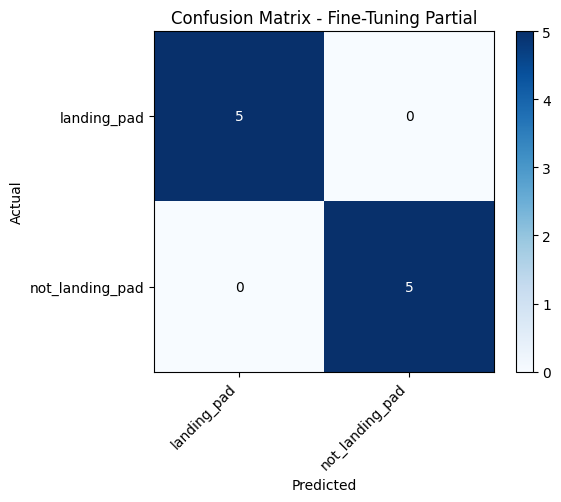

In [ ]:
best_model = models[best_mode]

# Kumpulkan prediksi pada test set
y_true = np.concatenate([y.numpy() for _, y in test_ds])
y_pred_probs = best_model.predict(test_ds, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

print(f"Classification Report ({best_mode}):\n")
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:")
print(cm)

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(num_classes))
ax.set_yticks(range(num_classes))
ax.set_xticklabels(class_names, rotation=45, ha='right')
ax.set_yticklabels(class_names)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix - {best_mode}')
for i in range(num_classes):
    for j in range(num_classes):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                color='white' if cm[i, j] > cm.max()/2 else 'black')
plt.colorbar(im)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

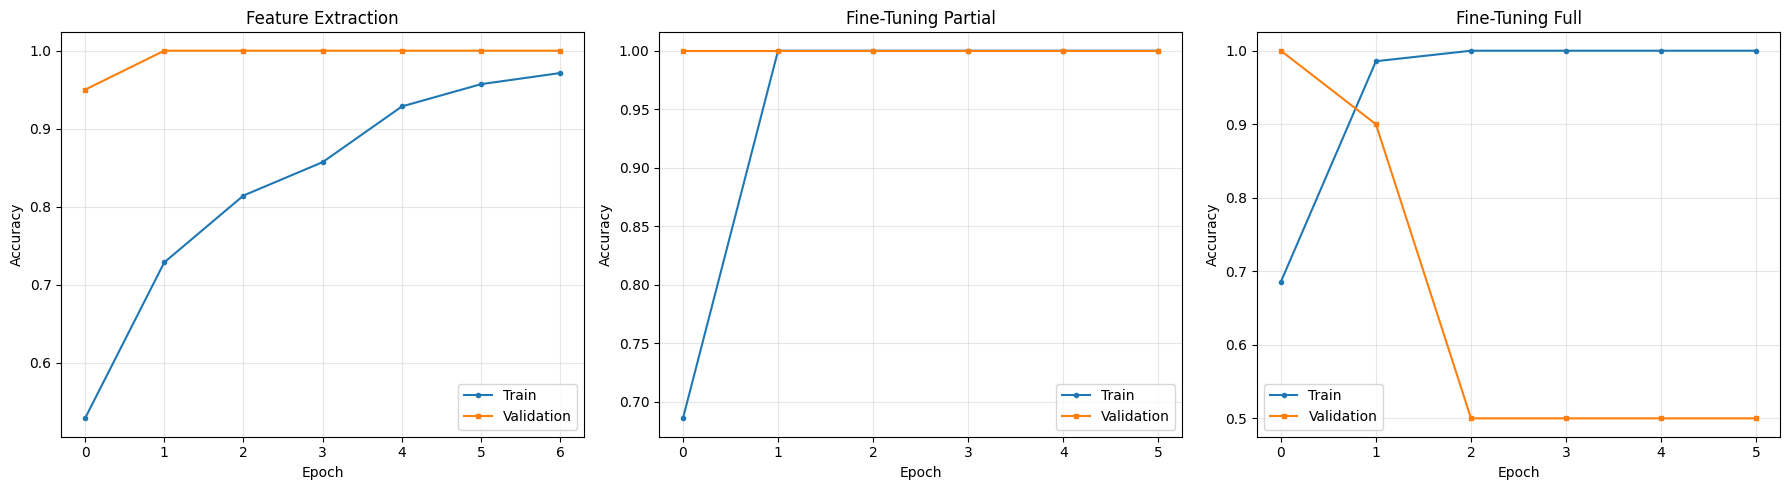

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, hist) in zip(axes, histories.items()):
    ax.plot(hist.history['accuracy'], label='Train', marker='o', markersize=3)
    ax.plot(hist.history['val_accuracy'], label='Validation', marker='s', markersize=3)
    ax.set_title(name)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy')
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('grafik_akurasi.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
sample_batch = next(iter(test_ds))[0]

# Warm-up (agar GPU stabil)
for _ in range(3):
    _ = best_model.predict(sample_batch, verbose=0)

# Ukur 10 kali
latencies = []
for _ in range(10):
    start = time.time()
    _ = best_model.predict(sample_batch, verbose=0)
    end = time.time()
    latencies.append((end - start) / len(sample_batch))

latency_per_image = float(np.mean(latencies))
latency_std = float(np.std(latencies))

print(f"Model terbaik: {best_mode}")
print(f"Latensi rata-rata: {latency_per_image*1000:.2f} ms/gambar (± {latency_std*1000:.2f} ms)")

Model terbaik: Fine-Tuning Partial
Latensi rata-rata: 19.58 ms/gambar (± 2.31 ms)


In [ ]:
best_model.save('best_model.keras')

for i, hist in enumerate([history_1, history_2, history_3], 1):
    with open(f'history_mode{i}.json', 'w') as f:
        json.dump(hist.history, f)

print("File tersimpan di Google Drive:")
print(os.listdir())

File tersimpan di Google Drive:
['metadata.csv', 'dataset_raw', 'split_train.csv', 'split_val.csv', 'split_test.csv', 'best_model_feature_extraction.keras', 'best_model_fine_tuning_partial.keras', 'best_model_fine_tuning_full.keras', 'hasil_validasi.csv', 'hasil_3_mode.csv', 'confusion_matrix.png', 'grafik_akurasi.png', 'best_model.keras', 'history_mode1.json', 'history_mode2.json', 'history_mode3.json']
